# Curso: Redes Neurais e Deep Learning

Prof. Denilson Alves Pereira 
https://sites.google.com/ufla.br/denilsonpereira/ 
Departamento de Ciência da Computação - 
Instituto de Ciências Exatas e Tecnológicas - 
Universidade Federal de Lavras

## Rede Neural Simples - Exemplo de Aplicação

Objetivo: apresentar um segundo exemplo de aplicação da rede neural simples desenvolvida na aula anterior.

Versão: Maio, 2021

## O Problema

Classificar dados de sinais coletados da ionosfera terrestre.

Entrada: instâncias compostas por 33 atributos representando os sinais coletados.

Saída: "G" (Good): o radar retorna que os elétrons livres na ionosfera mostram a evidência de algum tipo de estrutura; "B" (Bad): os elétrons livres não indicam estrutura.

## Arquitetura Geral

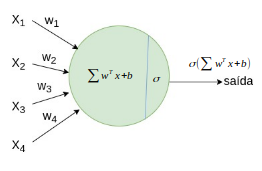

<p>
Será implementado um classificador binário usando a regressão logística (Logistic Regression Classifier) para resolver o problema.
    
**Expressões Matemáticas**:

Para um exemplo $x^{(i)}$:

$$
z^{(i)} = w^T x^{(i)} + b
$$

$$
\hat{y}^{(i)} = a^{(i)} = sigmoid(z^{(i)})
$$ 

$$
\mathcal{L}(a^{(i)}, y^{(i)}) =  - y^{(i)}  \log(a^{(i)}) - (1-y^{(i)} )  \log(1-a^{(i)})
$$

O custo é computado somando-se todos os exemplos de treino:
$$ J = \frac{1}{m} \sum_{i=1}^m \mathcal{L}(a^{(i)}, y^{(i)})$$

## Inicialização dos Parâmetros

Inicializa os parâmetros $w$ e $b$ com zeros.

O vetor $w$ tem o mesmo número de linhas da entrada X e uma única coluna. O parâmetro $b$ é um escalar.

In [1]:
!pip install numpy pandas matplotlib scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.2 MB/s eta 0:00:008 kB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 11.7 MB/s eta 0:00:00m eta 0:00:010:0101
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 10.0 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.1/306.1 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 467.4/467.4 kB 6.0 MB/s eta 0:00:000:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 8.7 MB/s eta 0:00:000m eta 0:00:010:01:01

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np # package for scientific computing
import pandas as pd # package for working with structured data 
import matplotlib.pyplot as plt # library to plot graphs in Python

In [3]:
def initializeParameters(dim):
    """
    Creates a vector of zeros of shape (dim, 1) for w and initializes b to 0.
    Argument:
        dim -- number of parameters for w
    Returns:
        w -- initialized vector w of shape (dim, 1)
        b -- initialized scalar b (bias)
    """
    w = np.zeros((dim, 1))
    b = 0.0
    return w, b

## Função Sigmóide

Computa $sigmoid(z) = \frac{1}{1 + e^{-(z)}}$

In [4]:
def sigmoid(z):
    """
    Compute the sigmoid activation function of z ==> S(z) = 1/1+e^(-z)
    Arguments:
        z -- A scalar or numpy array of any size.
    Return:
        s -- sigmoid(z)
    """
    s = 1/(1+np.exp(-z))
    return s

## Propagação para Frente (Feed Forward)

Computa $A = \sigma(w^T X + b) = (a^{(1)}, a^{(2)}, ..., a^{(m-1)}, a^{(m)})$

Dica: para entender como é feito o processamento vetorial dos dados, veja um exemplo em https://towardsdatascience.com/inroduction-to-neural-networks-in-python-7e0b422e6c24

In [5]:
def feed_forward(w, b, X):
    """
    Implement the forward propagation step
    Arguments:
        w -- weights, a numpy array of size (n,1)
        b -- bias, a scalar
        X -- data of size (n,m)
    Return:
        A -- sigmoid output for each data example (1,m)
    """
    A = sigmoid(np.dot(w.T,X)+b)  # activation
    return A

## Propagação para Trás (Backpropagation)

Computa a Função de Custo: $J = -\frac{1}{m}\sum_{i=1}^{m}y^{(i)}\log(a^{(i)})+(1-y^{(i)})\log(1-a^{(i)})$

Computa as derivadas parciais de $w$ e $b$ dadas pelas fórmulas:

$$ \frac{\partial J}{\partial w} = \frac{1}{m}X(A-Y)^T$$
$$ \frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^m (a^{(i)}-y^{(i)})$$

In [6]:
def backpropagation(A, X, Y):
    """
    Implement the backward propagation step
    Arguments:
        A -- activation function output for each data example (1,m)
        X -- input data, (n,m)
        Y -- true label vector, (1,m)
    Return:
        cost -- cost function output for logistic regression
        grads -- dictionary with:
            dw -- gradient of the loss with respect to w, (n,1) - same shape as w
            db -- gradient of the loss with respect to b, a scalar - same shape as b
    """
    m = X.shape[1]   # number of training examples
    cost = -(np.sum(Y*np.log(A)+(1-Y)*np.log(1-A)))/m   # compute cost
    dw = (np.dot(X,(A-Y).T))/m   # compute dw
    db = (np.sum(A-Y))/m         # compute db
    cost = np.squeeze(cost)      # remove axes of length one from cost
    grads = {"dw": dw,           # pack dw and db in a dictionary
             "db": db}
    return grads, cost

## Modelo de Treino

Executa o algoritmo de descida do gradiente para otimizar os valores dos parâmetros $w$ e $b$.

o objetivo é aprender $w$ e $b$ que minimiza a função de custo $J$. Para um parâmetro $\theta$, a regra de atualização é $\theta = \theta - \alpha \text{ } d\theta$, onde $\alpha$ é a taxa de aprendizagem.

In [7]:
def train(X, Y, epochs=1000, alpha=0.005, print_cost = False):
    """
    Optimize w and b by running a gradient descent algorithm
    Arguments:
        X -- input data, (n,m)
        Y -- true label vector, (1,m)
        epochs -- number of iterations for optimization
        alpha -- learning rate of the gradient descent update rule
        print_cost -- True to print the loss every 100 steps
    Returns:
        params -- dictionary containing the weights w and bias b
        costs -- list of all the costs computed during the optimization, this will be used to plot the learning curve.
    """
    costs = []                     # cost list for plot
    n = X.shape[0]                 # number of attributes
    w, b = initializeParameters(n) # initialize parameters w and b

    for i in range(epochs):
        # forward and backward propagation steps
        A = feed_forward(w, b, X)
        grads, cost = backpropagation(A, X, Y)
        # retrieve derivatives from grads
        dw = grads["dw"]
        db = grads["db"]
        # update rule
        w = w - alpha * dw
        b = b - alpha * db
        # record the costs
        if i % 100 == 0:
            costs.append(cost)
        # print the cost every 100 training iterations
        if print_cost and i % 100 == 0:
            print ("Cost after iteration %i: %f" %(i, cost))
    params = {"w": w,
              "b": b}
    return params, costs

## Predição de Novos Valores

Usa os valores de $w$ e $b$ aprendidos (treinados) para predizer os rótulos de uma nova entrada X. A função é composta de dois passos:

1. Calcula $\hat{Y} = A = \sigma(w^T X + b)$ por meio da função feed_forward

2. Converte as saídas em zero (se ativação <= 0.5) ou 1 (se ativação > 0.5)

In [8]:
def predict(w, b, X):
    '''
    Predict output on new and unseen input data using learned logistic regression parameters (w, b)
    Arguments:
        w -- weights, a numpy array of size (n,1)
        b -- bias, a scalar
        X -- input data, (n,m)
    Returns:
        Y_pred -- a numpy array (1,m) containing all predictions (0/1) for the inputs in X
    '''
    m = X.shape[1]
    Y_pred = np.zeros((1,m))
    w = w.reshape(X.shape[0], 1)
    # compute output A
    A = feed_forward(w, b, X)
    # convert output into 0 (if activation <= 0.5) or 1 (if activation > 0.5)
    for i in range(A.shape[1]):
        if A[0,i] <= 0.5:
            Y_pred[0,i] = 0
        else:
            Y_pred[0,i] = 1
    return Y_pred

## Dados para Treino e Teste

Fonte: https://www.kaggle.com/prashant111/ionosphere?select=ionosphere_data.csv

In [9]:
df = pd.read_csv('ionosphere_data.csv')
df['column_a'] = df.column_a.astype('float64') # convert boolean feature into numeric
df.drop(columns=['column_b'], inplace=True) # remove useless feature
df.head() # display dataset first lines


,column_a,column_c,column_d,column_e,column_f,column_g,column_h,column_i,column_j,column_k,...,column_z,column_aa,column_ab,column_ac,column_ad,column_ae,column_af,column_ag,column_ah,column_ai
0,1.0,0.99539,-0.05889,0.85243,0.02306,0.83398,-0.37708,1.00000,0.03760,0.85243,...,-0.51171,0.41078,-0.46168,0.21266,-0.34090,0.42267,-0.54487,0.18641,-0.45300,g
1,1.0,1.00000,-0.18829,0.93035,-0.36156,-0.10868,-0.93597,1.00000,-0.04549,0.50874,...,-0.26569,-0.20468,-0.18401,-0.19040,-0.11593,-0.16626,-0.06288,-0.13738,-0.02447,b
2,1.0,1.00000,-0.03365,1.00000,0.00485,1.00000,-0.12062,0.88965,0.01198,0.73082,...,-0.40220,0.58984,-0.22145,0.43100,-0.17365,0.60436,-0.24180,0.56045,-0.38238,g
3,1.0,1.00000,-0.45161,1.00000,1.00000,0.71216,-1.00000,0.00000,0.00000,0.00000,...,0.90695,0.51613,1.00000,1.00000,-0.20099,0.25682,1.00000,-0.32382,1.00000,b
4,1.0,1.00000,-0.02401,0.94140,0.06531,0.92106,-0.23255,0.77152,-0.16399,0.52798,...,-0.65158,0.13290,-0.53206,0.02431,-0.62197,-0.05707,-0.59573,-0.04608,-0.65697,g


In [10]:
# Encoding the output class
df.rename(columns={'column_ai': 'label'}, inplace=True)
encoding = {'g': 1, 'b': 0}
df["label"] = df["label"].replace(encoding)
df["label"] = df["label"].astype("category")
df.head()

,column_a,column_c,column_d,column_e,column_f,column_g,column_h,column_i,column_j,column_k,...,column_z,column_aa,column_ab,column_ac,column_ad,column_ae,column_af,column_ag,column_ah,label
0,1.0,0.99539,-0.05889,0.85243,0.02306,0.83398,-0.37708,1.00000,0.03760,0.85243,...,-0.51171,0.41078,-0.46168,0.21266,-0.34090,0.42267,-0.54487,0.18641,-0.45300,1
1,1.0,1.00000,-0.18829,0.93035,-0.36156,-0.10868,-0.93597,1.00000,-0.04549,0.50874,...,-0.26569,-0.20468,-0.18401,-0.19040,-0.11593,-0.16626,-0.06288,-0.13738,-0.02447,0
2,1.0,1.00000,-0.03365,1.00000,0.00485,1.00000,-0.12062,0.88965,0.01198,0.73082,...,-0.40220,0.58984,-0.22145,0.43100,-0.17365,0.60436,-0.24180,0.56045,-0.38238,1
3,1.0,1.00000,-0.45161,1.00000,1.00000,0.71216,-1.00000,0.00000,0.00000,0.00000,...,0.90695,0.51613,1.00000,1.00000,-0.20099,0.25682,1.00000,-0.32382,1.00000,0
4,1.0,1.00000,-0.02401,0.94140,0.06531,0.92106,-0.23255,0.77152,-0.16399,0.52798,...,-0.65158,0.13290,-0.53206,0.02431,-0.62197,-0.05707,-0.59573,-0.04608,-0.65697,1


Documentação de *train_test_split*: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html <br>
A função divide os dados em partições de treino e teste, de acordo com a proporção especificada pelo parâmetro *test_size*. <br>
O parâmetro *random_state* é usado para deixar os resultados reproduzíveis para fins de avaliação do exercício.

In [11]:
# Preparing the dataset for training and test
from sklearn.model_selection import train_test_split
X = df.values[:,:-1]
y = df.values[:,-1]
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=7)

Documentação de *fit_transform*: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html <br>
A função modifica o valor da cada atributo de cada instância dos dados com base na média e no desvio padrão do conjunto de dados.

In [12]:
# Standardize features by removing the mean and scaling to unit variance
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# The boolean feature does not need to be normalized.
x_train[:,1:] = scaler.fit_transform(x_train[:,1:])
x_test[:,1:]  = scaler.fit_transform(x_test[:,1:])

In [13]:
# input training data
train_set_X = np.array(x_train).T
# output training data
train_set_Y = np.array([y_train])

In [14]:
# input test data
test_set_X = np.array(x_test).T
# output test data
test_set_Y = np.array([y_test])

In [15]:
n = train_set_X.shape[0] # number of attributes
m = train_set_X.shape[1] # number of training examples

print ("Number of attributes: n = " + str(n))
print ("Number of training examples: m = " + str(m))
print ("Train set X shape: " + str(train_set_X.shape))
print ("Train set Y shape: " + str(train_set_Y.shape))
print ("Test set X shape: " + str(test_set_X.shape))
print ("Test set Y shape: " + str(test_set_Y.shape))

Number of attributes: n = 33
Number of training examples: m = 280
Train set X shape: (33, 280)
Train set Y shape: (1, 280)
Test set X shape: (33, 71)
Test set Y shape: (1, 71)


## Avaliação do Modelo

A avaliação é composta pelos seguintes passos:
    
1. Usa os dados de treinamento para gerar o modelo de aprendizagem (aprender $w$ e $b$)

2. Calcula a acurácia obtida pelo modelo de treino

3. Obtém a predição a partir dos dados de teste, com os parâmetros aprendidos

4. Calcula a acurácia obtida nos dados de teste. Esta acurácia é normalmente menor do que aquela obtida pelo modelo de treinamento.

Observe que o custo diminui com o aumento do número de iterações. Altere o número de iterações (epochs) e veja o efeito no custo e no resultado da acurácia.

In [16]:
# model evaluation

# training
print("Training...")
params, costs = train(train_set_X, train_set_Y, epochs = 1000, alpha = 0.005, print_cost = True)
w = params["w"] # trained w
b = params["b"] # traind b

# training accuracy
Y_pred = predict(w, b, train_set_X)
print("Train predictions = " + str(Y_pred))
print("Train accuracy: {} %".format(100 - np.mean(np.abs(Y_pred - train_set_Y)) * 100))

# testing
print("\nTesting...")
Y_pred = predict(w, b, test_set_X)
print("Test predictions = " + str(Y_pred))
print("Test accuracy: {} %".format(100 - np.mean(np.abs(Y_pred - test_set_Y)) * 100))

Training...
Cost after iteration 0: 0.693147
Cost after iteration 100: 0.558833
Cost after iteration 200: 0.489298
Cost after iteration 300: 0.446583
Cost after iteration 400: 0.417756
Cost after iteration 500: 0.396970
Cost after iteration 600: 0.381214
Cost after iteration 700: 0.368802
Cost after iteration 800: 0.358722
Cost after iteration 900: 0.350334
Train predictions = [[1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1.
  1. 0. 1. 0. 1. 1. 1. 0. 0. 1. 0. 1. 1. 1. 1. 0. 0. 0. 0. 1. 0. 1. 1. 0.
  1. 0. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 0. 1. 0. 1. 1. 0. 0. 0. 0. 1. 1.
  1. 1. 1. 1. 1. 0. 1. 1. 0. 1. 0. 1. 0. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 0. 1. 0. 1. 0. 0. 1. 1. 1. 1. 1. 1. 0. 1. 1. 0. 0. 1. 1.
  1. 0. 1. 1. 1. 0. 1. 1. 0. 1. 0. 0. 0. 1. 1. 1. 1. 1. 0. 1. 1. 0. 1. 1.
  0. 1. 1. 0. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 0. 0. 1. 0. 0. 1.
  0. 0. 1. 1. 0. 1. 0. 0. 0. 1. 0. 1. 0. 1. 1. 1. 0. 1. 0. 1. 1. 1. 1. 1.
  1. 0. 0. 1. 0. 1. 1. 1. 1.